<a href="https://colab.research.google.com/github/Rigen-Manandhar/BigData/blob/main/BigData_Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Report: Big Data Process for Nepal Education Statistics


##Step 1: Data Source and Automated Acquisition


###Identified Data Source

The dataset is sourced from Open Data Nepal, titled "Province Wise Higher Education Statistics". It contains enrollment numbers across Nepal and its seven provinces for different education levels:

ECD/PPC (Early Childhood Development/Pre-primary)

Basic (1–5)

Basic (6–8)

Secondary (9–10)

Secondary (11–12)

Grand Total (1–12)

Although titled "higher education," the data actually covers school-level education (ECD to grade 12), which still offers valuable insights into provincial disparities, enrollment distribution, and education infrastructure.

###How We Aim to Use It for Insight Generation


*   Compare enrollment across provinces to identify regions with high/low access to education.


*   Analyze the composition of enrollment by level within each province (e.g., do some provinces have a higher proportion of secondary students?).



*   Detect anomalies or outliers (e.g., a province with unusually low ECD
enrollment).



*   Group provinces with similar enrollment profiles to inform targeted policy

     interventions.



###Automation of Data Acquisition


If the dataset is updated periodically, we can automate downloads using a Python script. The typical approach:



1. Inspect the dataset page to find a direct download link (often a CSV/Excel file).

2. Use the requests library to fetch the file.

3. Schedule the script to run daily/weekly using cron (Linux/macOS) or Task Scheduler (Windows).



In [ ]:
import requests
url = "https://drive.google.com/uc?export=download&id=1SNy-IinckUQoa3PIb_g50B43y7-kTJAP"
response = requests.get(url)
with open("education_data.csv", "wb") as f:
    f.write(response.content)

##Step 2: Data Exploration, Understanding, Transformation, and Model Training

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1SNy-IinckUQoa3PIb_g50B43y7-kTJAP")

# Display basic info
print(df.info())
print(df.head())

# Check for missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Educational Level  6 non-null      object
 1   Nepal              6 non-null      int64 
 2   Province 1         6 non-null      int64 
 3   Province 2         6 non-null      int64 
 4   Province 3         6 non-null      int64 
 5   Gandaki            6 non-null      int64 
 6   Province 5         6 non-null      int64 
 7   Karnali            6 non-null      int64 
 8   Province 7         6 non-null      int64 
dtypes: int64(8), object(1)
memory usage: 564.0+ bytes
None
   Educational Level    Nepal  Province 1  Province 2  Province 3  Gandaki  \
0            ECD/PPC   958127      155778      122366      209522    99413   
1        Basic (1-5)  3970016      589060      801139      712455   331051   
2        Basic (6-8)  1866716      311470      256621      395824   196122   
3   Seconda

In [ ]:
print(df.columns.tolist())

['Educational Level', 'Nepal', 'Province 1', 'Province 2', 'Province 3', 'Gandaki', 'Province 5', 'Karnali', 'Province 7']


Output observations: No missing values; columns are correctly typed (all numeric except "Educational Level").

###2.2 Data Transformation

Reshape the data from wide to long format for easier plotting and analysis:



In [ ]:
# Melt the dataframe to have 'Province' and 'Enrollment' columns
df_long = df.melt(id_vars=['Educational Level'],
                  value_vars=['Nepal', 'Province 1', 'Province 2', 'Province 3',
                              'Gandaki', 'Province 5', 'Karnali', 'Province 7'],
                  var_name='Province', value_name='Enrollment')

# Exclude the 'Nepal' row if we want only province-level comparisons (optional)
df_provinces = df_long[df_long['Province'] != 'Nepal'].copy()

# Verify
print(df_provinces.head())

    Educational Level    Province  Enrollment
6             ECD/PPC  Province 1      155778
7         Basic (1-5)  Province 1      589060
8         Basic (6-8)  Province 1      311470
9    Secondary (9-10)  Province 1      164215
10  Secondary (11-12)  Province 1      110258


##2.3 Exploratory Visualizations
###a) Total enrollment by province (all levels combined)

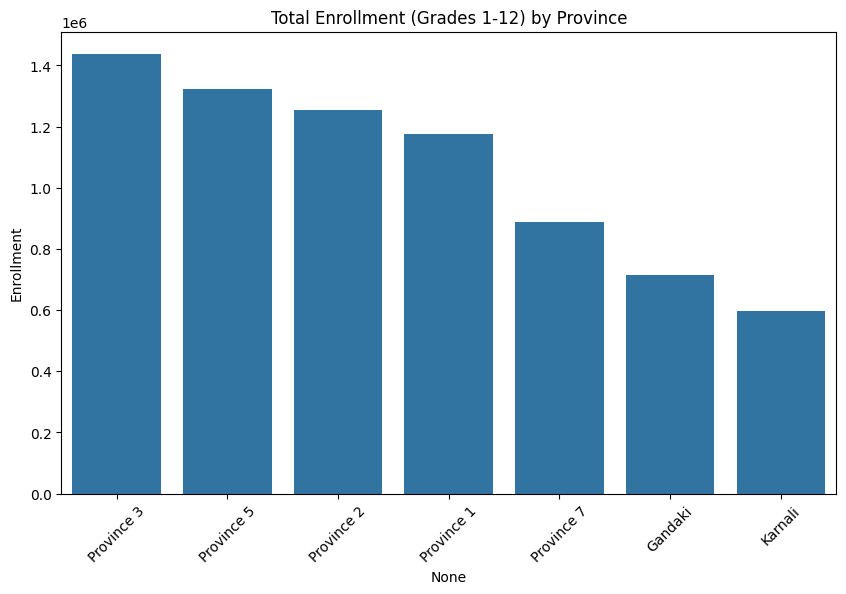

In [ ]:
# Use the Grand Total row for overall comparison
total_enrollment = df[df['Educational Level'] == 'Grand Total (1-12)']
total_enrollment = total_enrollment.drop(columns=['Educational Level', 'Nepal']).T
total_enrollment.columns = ['Total Enrollment']
total_enrollment.sort_values(by='Total Enrollment', ascending=False, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(x=total_enrollment.index, y='Total Enrollment', data=total_enrollment)
plt.title('Total Enrollment (Grades 1-12) by Province')
plt.xticks(rotation=45)
plt.ylabel('Enrollment')
plt.show()

###b) Enrollment by educational level for each province (stacked bar)

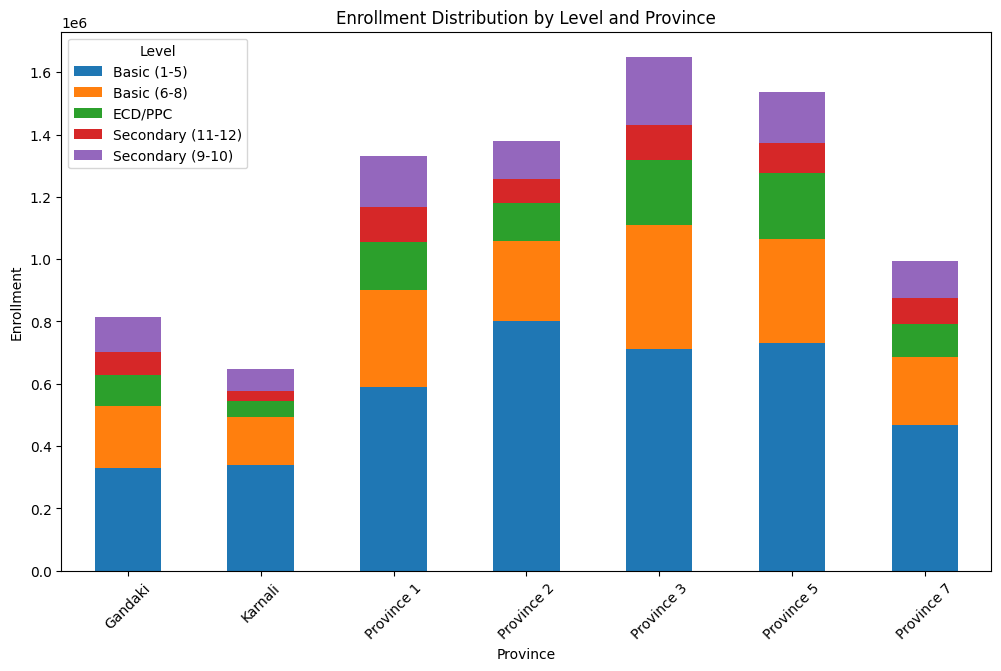

In [ ]:
# Prepare data: pivot so levels are columns, provinces are rows
pivot_df = df_provinces.pivot(index='Province', columns='Educational Level', values='Enrollment')
pivot_df = pivot_df.drop(columns=['Grand Total (1-12)'])  # avoid double-counting

pivot_df.plot(kind='bar', stacked=True, figsize=(12,7))
plt.title('Enrollment Distribution by Level and Province')
plt.ylabel('Enrollment')
plt.xticks(rotation=45)
plt.legend(title='Level')
plt.show()

###c) Heatmap of enrollment shares (to spot patterns)

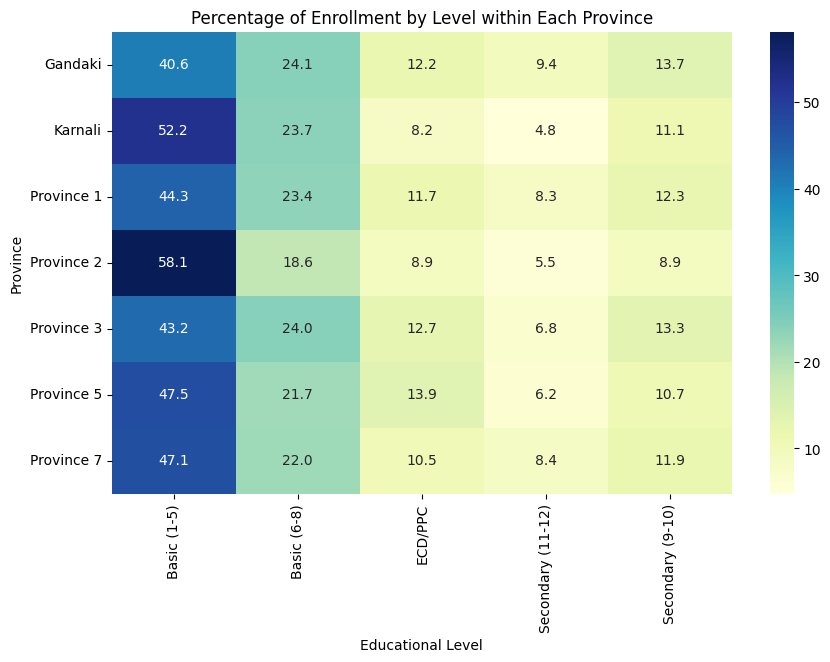

In [ ]:
# Calculate percentage of each level within each province
pivot_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10,6))
sns.heatmap(pivot_percent, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Percentage of Enrollment by Level within Each Province')
plt.show()

###d) Boxplot to see distribution of enrollment across provinces by level

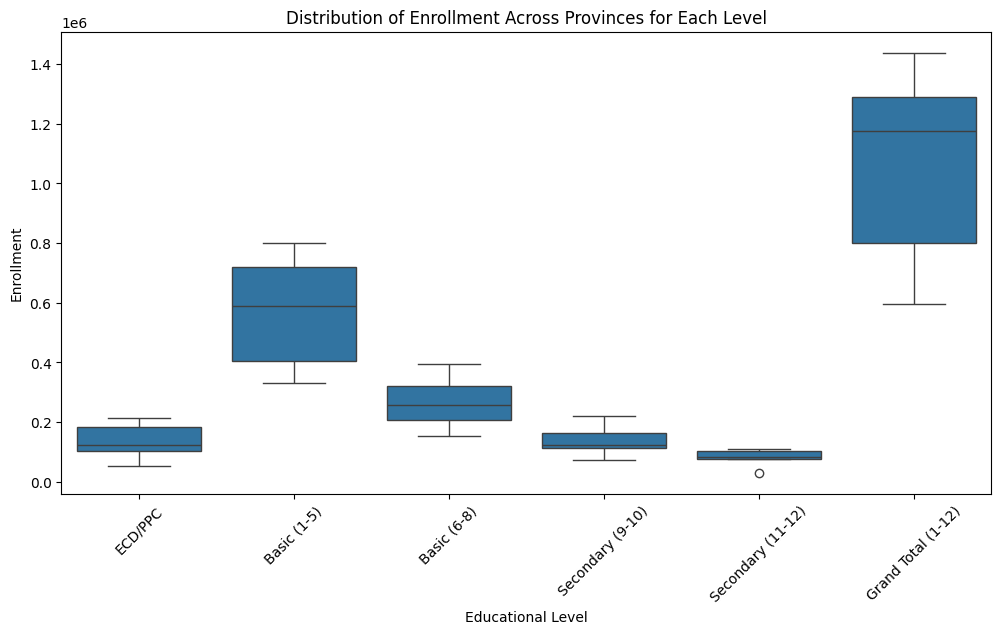

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_provinces, x='Educational Level', y='Enrollment')
plt.xticks(rotation=45)
plt.title('Distribution of Enrollment Across Provinces for Each Level')
plt.show()

###2.4 Model Training (Conditional – Clustering)
Since we have only one year of data, predictive modeling (e.g., forecasting) isn’t feasible. However, we can apply unsupervised learning to group provinces with similar enrollment profiles.

K-Means Clustering on Enrollment Composition

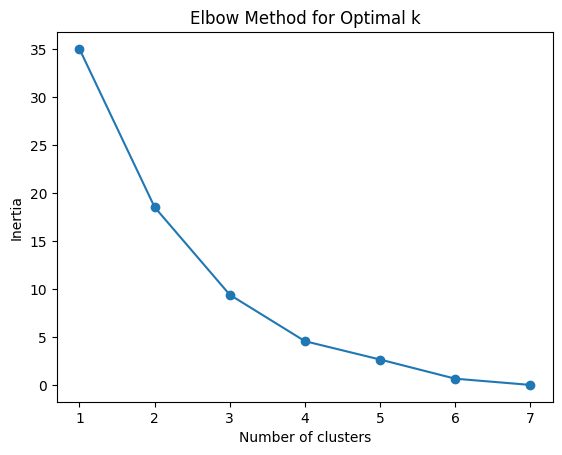

Educational Level  Basic (1-5)  Basic (6-8)    ECD/PPC  Secondary (11-12)  \
Province                                                                    
Gandaki              40.645189    24.079117  12.205552           9.381453   
Karnali              52.207982    23.730088   8.169173           4.789112   
Province 1           44.264233    23.405053  11.705758           8.285210   
Province 2           58.137766    18.622701   8.879965           5.504060   
Province 3           43.228319    24.016683  12.712780           6.759516   
Province 5           47.476656    21.724299  13.900894           6.240698   
Province 7           47.142575    22.047741  10.519429           8.378577   

Educational Level  Secondary (9-10)  Cluster  
Province                                      
Gandaki                   13.688689        0  
Karnali                   11.103644        2  
Province 1                12.339746        0  
Province 2                 8.855509        1  
Province 3              

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use the pivot_percent data (or raw enrollment numbers) for clustering
# We'll use percentages to focus on composition, not absolute size
X = pivot_percent.values  # provinces x levels

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters (Elbow method)
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,8), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Choose k=3 (example, based on elbow)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
pivot_percent['Cluster'] = clusters

print(pivot_percent)

Interpretation: Provinces in the same cluster have similar enrollment distributions across education levels.

Include all plots and code outputs in your report.



##Step 3: Generate Insights
From the exploration and clustering, we derive the following insights:

1. Province 3 (Bagmati) has the highest total enrollment (1.44 million in grades 1–12), followed by Province 2 (1.26 million) and Province 5 (1.32 million). Karnali has the lowest (0.60 million), indicating significant regional disparity.


2. ECD/PPC enrollment is relatively low compared to basic levels in all provinces. Province 2 has the highest ECD numbers (122k), possibly reflecting population size or early education initiatives.


3. Secondary (11–12) enrollment drops sharply in every province, suggesting high dropout rates after grade 10. The drop is most severe in Karnali (from 72k in grades 9–10 to 31k in 11–12) and Province 2 (122k to 76k).


4. Province-wise composition:


    Province 3 and Gandaki have a slightly higher share of secondary students, indicating better retention.

    Karnali has a higher proportion of basic level students, possibly due to limited access to higher secondary schools.

    The heatmap reveals that Province 7 has a relatively larger share of ECD enrollment, suggesting successful early childhood programs.


5. Clustering results (with k=3):


    Cluster 0: Provinces 1, 3, Gandaki, 5 – balanced composition with slightly above-average secondary shares.

    Cluster 1: Provinces 2 and 7 – higher ECD and basic (1–5) shares.

    Cluster 2: Karnali alone – distinct with the lowest secondary shares and highest basic (6–8) proportion.
    
    These clusters can guide customized education policies.

6. Anomaly detection: The unusually low ECD enrollment in Karnali (53k) relative to its basic level (338k) may indicate underreporting or lack of pre-primary facilities.